# D2 — Online Retail: Luật kết hợp + Gom cụm

## 1. Nguồn – giấy phép – quy mô

| Mục | Thông tin |
|---|---|
| Dataset | Online Retail |
| Link | https://archive.ics.uci.edu/dataset/352/online+retail |
| Đơn vị công bố | UCI Machine Learning Repository |
| Tác giả dữ liệu | Daqing Chen |
| Giấy phép | CC BY 4.0 |
| Ngày tải/truy cập | 25/08/2026 |
| Quy mô công bố | 541,909 bản ghi, 8 thuộc tính |
| Kỹ thuật yêu cầu | **Luật kết hợp + Gom cụm** |

**Tri thức lĩnh vực:** đây là dữ liệu giao dịch bán lẻ trực tuyến. Mỗi hóa đơn có nhiều sản phẩm nên phù hợp với **luật kết hợp** để tìm sản phẩm thường xuất hiện cùng nhau. Sau khi tổng hợp theo khách hàng thành RFM/đặc trưng hành vi, dữ liệu phù hợp với **gom cụm** để phân khúc khách hàng.

## 2. Từ điển dữ liệu

| Thuộc tính | Ý nghĩa | Kiểu | Thang đo | Miền giá trị |
|---|---|---|---|---|
| InvoiceNo | Mã hóa đơn | string | danh nghĩa | mã hóa đơn; `C` đầu cho hủy |
| StockCode | Mã sản phẩm | string | danh nghĩa | mã sản phẩm |
| Description | Tên/mô tả sản phẩm | string | danh nghĩa | chuỗi |
| Quantity | Số lượng | int | tỷ lệ | có thể âm khi trả hàng |
| InvoiceDate | Thời gian giao dịch | datetime | khoảng/thời gian | ngày giờ |
| UnitPrice | Giá đơn vị | float | tỷ lệ | >= 0 với giao dịch hợp lệ |
| CustomerID | Mã khách hàng | string/float | danh nghĩa | mã định danh |
| Country | Quốc gia | string | danh nghĩa | tên quốc gia |

In [1]:
import os, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import zscore
from ucimlrepo import fetch_ucirepo
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
warnings.filterwarnings("ignore")
os.makedirs("outputs",exist_ok=True); os.makedirs("outputs/figures",exist_ok=True)

online=fetch_ucirepo(id=352)
df=online.data.features.copy()
print("Shape:",df.shape)
display(df.head())
display(df.dtypes.to_frame("dtype"))

Shape: (541909, 6)


,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


,dtype
Description,object
Quantity,int64
InvoiceDate,object
UnitPrice,float64
CustomerID,float64
Country,object


## 3. Khảo sát giá trị thiếu

`CustomerID` thường có thiếu trong dữ liệu giao dịch; với luật kết hợp có thể không cần CustomerID. Với gom cụm theo khách hàng, các bản ghi thiếu CustomerID không thể gán chắc chắn vào một khách hàng nên được loại **chỉ trong bước xây dựng RFM**. `Description` nếu thiếu có thể dùng `StockCode` hoặc loại trong bước luật kết hợp tùy mục tiêu.

In [2]:
missing=pd.DataFrame({
    "missing_count":df.isna().sum(),
    "missing_percent":(df.isna().mean()*100).round(2)
}).sort_values("missing_percent",ascending=False)
display(missing)
missing.to_csv("outputs/missing_report.csv",encoding="utf-8-sig")

,missing_count,missing_percent
CustomerID,135080,24.93
Description,1454,0.27
Quantity,0,0.00
InvoiceDate,0,0.00
UnitPrice,0,0.00
Country,0,0.00


## 4. Nhiễu/ngoại lai: IQR + Z-score + Boxplot

Các biến số chính: `Quantity`, `UnitPrice`. Giá trị âm hoặc hóa đơn bắt đầu bằng `C` có thể biểu diễn hủy/trả hàng — đây là **nghiệp vụ**, không tự động coi là lỗi. Tuy nhiên, để khai phá giỏ hàng và RFM mua hàng, ta lọc giao dịch mua hợp lệ: không hủy, Quantity > 0, UnitPrice > 0.

,attribute,Q1,Q3,IQR,lower,upper,IQR_count,Zscore_count
0,Quantity,1.00,10.00,9.00,-12.50,23.50,58619,346
1,UnitPrice,1.25,4.13,2.88,-3.07,8.45,39627,374


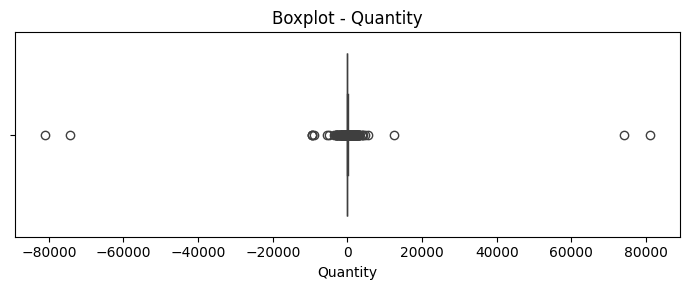

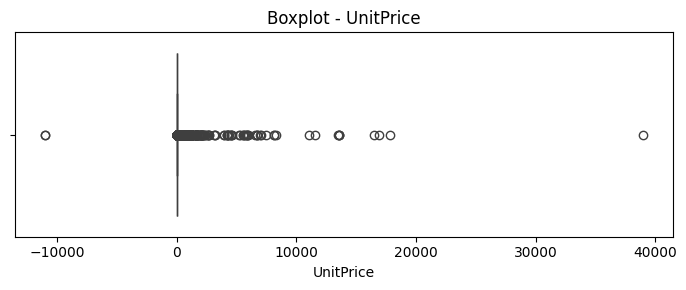

In [3]:
num_cols=["Quantity","UnitPrice"]
rows=[]
for c in num_cols:
    s=df[c].dropna()
    q1,q3=s.quantile(.25),s.quantile(.75); iqr=q3-q1
    lo,hi=q1-1.5*iqr,q3+1.5*iqr
    iqr_n=((s<lo)|(s>hi)).sum()
    z_n=(np.abs(zscore(s))>3).sum() if s.std()!=0 else 0
    rows.append([c,q1,q3,iqr,lo,hi,int(iqr_n),int(z_n)])
outliers=pd.DataFrame(rows,columns=["attribute","Q1","Q3","IQR","lower","upper","IQR_count","Zscore_count"])
display(outliers)
outliers.to_csv("outputs/outlier_report.csv",index=False,encoding="utf-8-sig")

for c in num_cols:
    plt.figure(figsize=(7,3)); sns.boxplot(x=df[c])
    plt.title(f"Boxplot - {c}"); plt.tight_layout()
    plt.savefig(f"outputs/figures/boxplot_{c}.png",dpi=140); plt.show()

## 5. Đề xuất thêm/xóa/biến đổi thuộc tính

- Loại khỏi luật kết hợp: hóa đơn hủy, số lượng <= 0, giá <= 0.
- Không dùng `InvoiceNo` như item vì đây là khóa giao dịch.
- Dùng `Description` làm item; có thể thay bằng `StockCode` nếu tên sản phẩm nhiễu.
- Tạo `TotalPrice = Quantity * UnitPrice`.
- Tạo RFM cho gom cụm: `Recency`, `Frequency`, `Monetary`.
- Chuẩn hóa RFM và dùng log1p cho các biến lệch phải.
- Không dùng các ID như biến số liên tục.

In [4]:
data=df.copy()
data["InvoiceNo"]=data["InvoiceNo"].astype(str)
data["StockCode"]=data["StockCode"].astype(str)
data["Description"]=data["Description"].astype("string").str.strip()
data["InvoiceDate"]=pd.to_datetime(data["InvoiceDate"])
data["CustomerID"]=pd.to_numeric(data["CustomerID"],errors="coerce")

clean=data[
    (~data["InvoiceNo"].str.startswith("C",na=False)) &
    (data["Quantity"]>0) &
    (data["UnitPrice"]>0)
].copy()
clean["TotalPrice"]=clean["Quantity"]*clean["UnitPrice"]
print("Sau lọc giao dịch hợp lệ:",clean.shape)
display(clean.head())

KeyError: 'InvoiceNo'

## 6. Thực nghiệm 1 — Luật kết hợp

Để tránh ma trận quá lớn, thực nghiệm lấy một phân đoạn có thể tái lập: hóa đơn của `United Kingdom`, chọn các sản phẩm phổ biến nhất. Ngưỡng `min_support`, `confidence`, `lift` có thể điều chỉnh.

In [ ]:
market=clean[clean["Country"].eq("United Kingdom")].dropna(subset=["Description"]).copy()
top_items=market["Description"].value_counts().head(100).index
market=market[market["Description"].isin(top_items)]

basket=(market.groupby(["InvoiceNo","Description"])["Quantity"]
        .sum().unstack(fill_value=0))
basket=(basket>0).astype(bool)
print("Basket shape:",basket.shape)

freq=apriori(basket,min_support=0.01,use_colnames=True)
rules=association_rules(freq,metric="confidence",min_threshold=0.25)
rules=rules[rules["lift"]>1].sort_values(["lift","confidence"],ascending=False)
display(freq.sort_values("support",ascending=False).head(20))
display(rules[["antecedents","consequents","support","confidence","lift"]].head(30))
freq.to_csv("outputs/frequent_itemsets.csv",index=False,encoding="utf-8-sig")
rules.to_csv("outputs/association_rules.csv",index=False,encoding="utf-8-sig")

## 7. Thực nghiệm 2 — Gom cụm khách hàng bằng RFM

RFM:
- Recency: số ngày kể từ lần mua gần nhất đến mốc quan sát.
- Frequency: số hóa đơn.
- Monetary: tổng giá trị mua.

In [ ]:
rfm_data=clean.dropna(subset=["CustomerID"]).copy()
snapshot=rfm_data["InvoiceDate"].max()+pd.Timedelta(days=1)
rfm=rfm_data.groupby("CustomerID").agg(
    Recency=("InvoiceDate",lambda x:(snapshot-x.max()).days),
    Frequency=("InvoiceNo","nunique"),
    Monetary=("TotalPrice","sum")
).reset_index()

rfm_model=rfm.copy()
rfm_model[["Frequency","Monetary"]]=np.log1p(rfm_model[["Frequency","Monetary"]])
Z=StandardScaler().fit_transform(rfm_model[["Recency","Frequency","Monetary"]])

scores=[]
for k in range(2,9):
    km=KMeans(n_clusters=k,random_state=42,n_init=20)
    lab=km.fit_predict(Z)
    scores.append({"k":k,"inertia":km.inertia_,"silhouette":silhouette_score(Z,lab)})
scores=pd.DataFrame(scores)
display(scores)
scores.to_csv("outputs/clustering_scores.csv",index=False,encoding="utf-8-sig")

best_k=int(scores.loc[scores["silhouette"].idxmax(),"k"])
km=KMeans(n_clusters=best_k,random_state=42,n_init=20)
rfm["Cluster"]=km.fit_predict(Z)
display(rfm.groupby("Cluster")[["Recency","Frequency","Monetary"]].mean().round(2))

P=PCA(n_components=2,random_state=42).fit_transform(Z)
plt.figure(figsize=(7,5))
sns.scatterplot(x=P[:,0],y=P[:,1],hue=rfm["Cluster"],palette="tab10",s=20)
plt.title(f"Online Retail customer clustering (k={best_k})")
plt.tight_layout(); plt.savefig("outputs/figures/d2_clusters.png",dpi=150); plt.show()
rfm.to_csv("outputs/rfm_with_clusters.csv",index=False,encoding="utf-8-sig")

## 8. Kết luận D2

- **Luật kết hợp phù hợp** vì mỗi hóa đơn là một giỏ sản phẩm.
- **Gom cụm phù hợp** sau khi tổng hợp dữ liệu giao dịch thành đặc trưng khách hàng.
- Ngoại lai nghiệp vụ được phân biệt với lỗi dữ liệu.
- Kết quả luật được đánh giá bằng support, confidence, lift.
- Số cụm được chọn theo silhouette score và kiểm tra thêm inertia.